In [74]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import numpy as np

In [75]:
data = np.array(
    [
        [1, 1],
        [3, 2],
        [2, 4],
        [3, 4],
        [2, 3],
    ]
)
labels = np.array([-1, 1, 1, 1, -1])

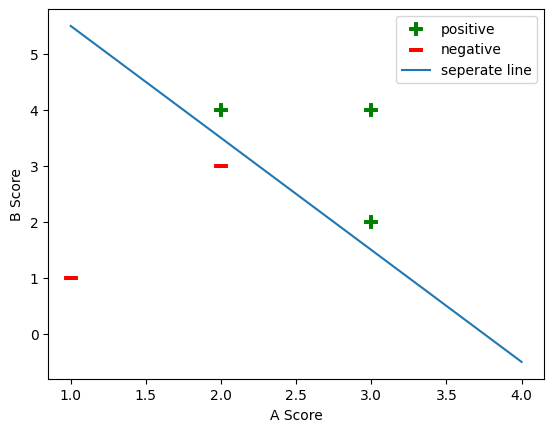

In [130]:
pos = data[np.where(labels == 1)]
plt.scatter(pos[:, 0], pos[:, 1], marker="+", lw=10, s=5, label="positive", c="green")

neg = data[np.where(labels == -1)]
plt.scatter(neg[:, 0], neg[:, 1], marker="|", lw=10, s=5, label="negative", c="red")
line = lambda x: -2 * x + 7.5
x = np.linspace(1, 4, 200)
plt.plot(x, [line(i) for i in x], label="seperate line")
plt.xlabel("A Score")
plt.ylabel("B Score")
plt.legend()

In [132]:
def learn(n: int, weights: list[float], lr: float):
    for i in range(n):
        ind = i % len(data)
        x = np.append(1, data[ind])
        score = np.sum(weights * x)
        pred = 1 if score > 0 else -1
        print(i + 1, weights, score, pred == labels[ind], sep=" & ")
        if pred == labels[ind]:
            continue
        weights += lr * labels[ind] * x
    weights /= weights[-1]
    weights *= -1
    return weights


weights = learn(5, np.array([-1, 0, 0], dtype=np.float64), lr=0.05)

1 & [-1.  0.  0.] & -1.0 & True
2 & [-1.  0.  0.] & -1.0 & False
3 & [-0.95  0.15  0.1 ] & -0.2499999999999999 & False
4 & [-0.9   0.25  0.3 ] & 1.0500000000000003 & True
5 & [-0.9   0.25  0.3 ] & 0.5000000000000002 & False


In [135]:
weights = learn(50, np.array([-1, 0, 0], dtype=np.float64), lr=0.005)

1 & [-1.  0.  0.] & -1.0 & True
2 & [-1.  0.  0.] & -1.0 & False
3 & [-0.995  0.015  0.01 ] & -0.9249999999999999 & False
4 & [-0.99   0.025  0.03 ] & -0.795 & False
5 & [-0.985  0.04   0.05 ] & -0.755 & True
6 & [-0.985  0.04   0.05 ] & -0.8949999999999999 & True
7 & [-0.985  0.04   0.05 ] & -0.765 & False
8 & [-0.98   0.055  0.06 ] & -0.63 & False
9 & [-0.975  0.065  0.08 ] & -0.46 & False
10 & [-0.97  0.08  0.1 ] & -0.5099999999999999 & True
11 & [-0.97  0.08  0.1 ] & -0.79 & True
12 & [-0.97  0.08  0.1 ] & -0.53 & False
13 & [-0.965  0.095  0.11 ] & -0.3349999999999999 & False
14 & [-0.96   0.105  0.13 ] & -0.125 & False
15 & [-0.955  0.12   0.15 ] & -0.265 & True
16 & [-0.955  0.12   0.15 ] & -0.6849999999999999 & True
17 & [-0.955  0.12   0.15 ] & -0.295 & False
18 & [-0.95   0.135  0.16 ] & -0.039999999999999925 & False
19 & [-0.945  0.145  0.18 ] & 0.21000000000000008 & True
20 & [-0.945  0.145  0.18 ] & -0.11499999999999988 & True
21 & [-0.945  0.145  0.18 ] & -0.6199999999999

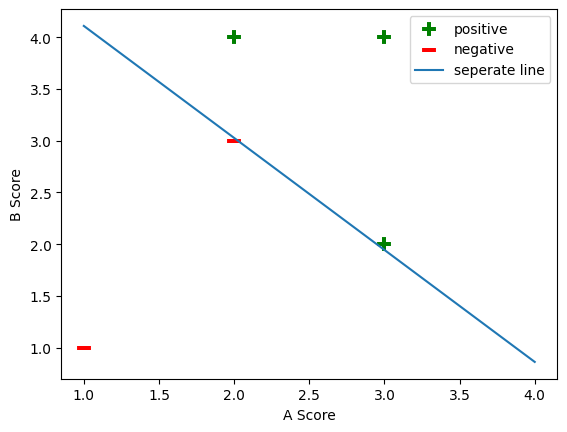

In [136]:
pos = data[np.where(labels == 1)]
plt.scatter(pos[:, 0], pos[:, 1], marker="+", lw=10, s=5, label="positive", c="green")

neg = data[np.where(labels == -1)]
plt.scatter(neg[:, 0], neg[:, 1], marker="|", lw=10, s=5, label="negative", c="red")
x = np.linspace(1, 4, 200)
plt.plot(x, x * weights[1] + weights[0], label="seperate line")
plt.xlabel("A Score")
plt.ylabel("B Score")
plt.legend()